In [471]:
from pathlib import Path
import dask.array as da
import pandas as pd
import anndata as ad
import napari
import numpy as np
from tqdm.auto import tqdm
import json

expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']


def timed_compute(volume):
    """
    Compute a lazy Dask array frame-by-frame with progress reporting.

    This function iterates over the leading axis of a Dask array (e.g. time),
    calls `.compute()` on each slice, and stacks the results into a single
    NumPy array. A tqdm progress bar is displayed to indicate progress.

    Parameters
    ----------
    volume : dask.array.Array
        A Dask array with at least one dimension (e.g. shape (T, ...)).
        The function will iterate over the first axis (axis=0).

    Returns
    -------
    numpy.ndarray
        A NumPy array with the same shape as `volume`, but fully realized
        in memory. The dtype is preserved from the Dask array.

    Notes
    -----
    - Each frame is computed independently, which can be helpful for
      monitoring performance and memory use on large arrays.
    - The returned array may be very large if `volume` is large.
      Ensure sufficient memory is available.
    """
    return np.stack([frame.compute() for frame in tqdm(volume)], axis=0)


In [2]:
root_dir = Path('/mnt/OPERA3/Nathan/Z_stack_tests/zarr')
rc_stem = "(3,3)"
store = root_dir / f"{rc_stem}.zarr"

# --- load images and segmentation ---
images = da.from_zarr(str(store / "images" / "0"), consolidated=False)   # (T,C,Z,Y,X)
masks  = da.from_zarr(str(store / "labels" / "masks"), consolidated=False)  # (T,Z,Y,X)

# --- load tracks (CSV preferred, fallback to AnnData) ---
# tracks_csv = root_dir / f"{rc_stem}_tracks.csv"
# if tracks_csv.exists():
#     tracks = pd.read_csv(tracks_csv)
# else:
adata = ad.read_zarr(str(store / "tables" / "quantified_tracks"))
tracks = adata.obs.reset_index(drop=True)

print("images:", images.shape)
print("masks:", masks.shape)
print("tracks:", tracks.shape)


/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/zarr/creation.py:250: UserWarning: ignoring keyword argument 'read_only'
  warn('ignoring keyword argument %r' % k)
/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/zarr/creation.py:250: UserWarning: ignoring keyword argument 'consolidated'
  warn('ignoring keyword argument %r' % k)


images: (97, 2, 25, 7992, 7992)
masks: (97, 25, 7992, 7992)
tracks: (1859520, 10)


In [243]:
tracks

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col
0,0,1,0,866.0,6511.0,18375.0,0.0,817.0,3.0,3.0
1,1,1,0,858.0,6514.0,16950.0,0.0,181.0,3.0,3.0
2,2,1,0,844.0,6532.0,13600.0,0.0,213.0,3.0,3.0
3,3,1,0,846.0,6536.0,16650.0,0.0,380.0,3.0,3.0
4,4,1,0,841.0,6559.0,16300.0,0.0,437.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...
92,92,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,93,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,94,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,95,8619,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [146]:
%%time
# full time axis
all_t = np.arange(tracks['t'].min(), tracks['t'].max() + 1, dtype=int)

# reindex each track-z group to break lines on missing timepoints
def expand_group(g):
    out = g.set_index('t').reindex(all_t)
    out['ID'] = g.name[0]
    out['z']  = g.name[1]
    return out.reset_index().rename(columns={'index': 't'})

tracks = (tracks
    .groupby(['ID', 'z'], group_keys=False)
    .apply(expand_group)
)

CPU times: user 45.3 s, sys: 355 ms, total: 45.6 s
Wall time: 45.6 s


<timed exec>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [149]:
napari_tracks = tracks[['ID', 't', 'z', 'y', 'x']].to_numpy(dtype=np.int64)
napari_tracks.shape

/home/dayn/miniconda3/envs/godspeed/lib/python3.10/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr


(3037167, 5)

In [9]:
viewer = napari.Viewer(title = 'inspecting tracks and quantifications')
viewer.add_image(images, channel_axis=1)
viewer.add_labels(masks)
viewer.add_tracks(napari_tracks)

<Tracks layer 'napari_tracks' at 0x76eb9c2b0130>

In [12]:
napari_tracks[:, 1].shape

(1859520,)

In [150]:
# features = {
#     'time': tracks['t'].values,
#     'mtb_area_px': tracks['mtb_area_px'].values
# }

features = {
    col: tracks[col].values
    for col in tracks.columns
}

In [21]:
viewer.layers['napari_tracks'].features = features

## Working with a subset of data

In [116]:
shapes = viewer.layers['Shapes'].data[0]

In [117]:
shapes

array([[  48.        ,   12.        , 1150.17435385, 3270.44807186],
       [  48.        ,   12.        , 1150.17435385, 5046.11438262],
       [  48.        ,   12.        , 3059.55047718, 5046.11438262],
       [  48.        ,   12.        , 3059.55047718, 3270.44807186]])

In [118]:
vertices = shapes[:,2:]
y0, y1 = int(np.floor(vertices[:, 0].min())), int(np.ceil(vertices[:, 0].max()))
x0, x1 = int(np.floor(vertices[:, 1].min())), int(np.ceil(vertices[:, 1].max()))
x0, x1, y0, y1

(3270, 5047, 1150, 3060)

In [119]:
images_roi = images[:, :, :, y0:y1, x0:x1]
masks_roi  = masks[:, :, y0:y1, x0:x1]


/tmp/ipykernel_7320/3407759134.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['y'] = roi_tracks['y'] - y0
/tmp/ipykernel_7320/3407759134.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['x'] = roi_tracks['x'] - x0


In [219]:
roi_tracks = tracks[(tracks['y'] >= y0) & (tracks['y'] < y1) &
                    (tracks['x'] >= x0) & (tracks['x'] < x1)]
roi_tracks['y'] = roi_tracks['y'] - y0
roi_tracks['x'] = roi_tracks['x'] - x0

/tmp/ipykernel_7320/493691589.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['y'] = roi_tracks['y'] - y0
/tmp/ipykernel_7320/493691589.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['x'] = roi_tracks['x'] - x0


In [66]:

images_roi = np.stack([frame.compute() for frame in tqdm(images_roi)], axis=0)

  0%|          | 0/97 [00:00<?, ?it/s]

In [71]:
viewer_2 = napari.Viewer(title = 'testing on subset')

In [90]:
scale = [1.0, 0.14949, 0.14949]

In [70]:
images_roi.shape

(97, 2, 25, 1910, 1777)

In [92]:
viewer_2.add_image(images_roi, channel_axis = 1, scale = scale)

[<Image layer 'Image' at 0x76eb9687f250>, <Image layer 'Image [1]' at 0x76eb9687d4b0>]

In [93]:
masks_rio = timed_compute(masks_roi)

  0%|          | 0/97 [00:00<?, ?it/s]

In [95]:
viewer_2.add_labels(masks_roi, scale = scale)

<Labels layer 'masks_roi' at 0x76eb7bc1e3b0>

In [121]:
napari_tracks =  roi_tracks[roi_tracks["z"] == 12][['ID', 't', 'z', 'y', 'x']].to_numpy(dtype=np.int64)
napari_tracks.shape

(3913, 5)

In [122]:
# features = {
#     'time': tracks['t'].values,
#     'mtb_area_px': tracks['mtb_area_px'].values
# }

features = {
    col: roi_tracks[col].values
    for col in roi_tracks.columns
}

In [123]:
napari_tracks

array([[ 237,    0,   12, 1411, 1358],
       [ 313,    0,   12,  175,  253],
       [ 397,    0,   12, 1203,  814],
       ...,
       [6658,   96,   12, 1716,   89],
       [6664,   96,   12, 1249, 1355],
       [7546,   96,   12, 1841,  610]])

In [113]:
viewer_2.add_tracks(napari_tracks, scale = scale,)# features = features)

<Tracks layer 'napari_tracks [1]' at 0x76eb96b50580>

In [125]:
scale

[1.0, 0.14949, 0.14949]

In [126]:
norm_scale = [1/0.14949, 1, 1]
for layer in viewer_2.layers:
    layer.scale = norm_scale

In [153]:
roi_tracks[roi_tracks['ID'] == 2280]

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col
0,0,2280,0,1739.0,1302.0,23125.0,0.0,868.0,3.0,3.0
48,48,2280,0,1735.0,1353.0,16575.0,0.0,572.0,3.0,3.0
52,52,2280,0,1717.0,1288.0,19775.0,0.0,171.0,3.0,3.0
54,54,2280,0,1722.0,1312.0,15650.0,0.0,222.0,3.0,3.0
59,59,2280,0,1722.0,1296.0,23275.0,0.0,223.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...
92,92,2280,24,1719.0,1268.0,16250.0,0.0,537.0,3.0,3.0
93,93,2280,24,1719.0,1279.0,15825.0,0.0,444.0,3.0,3.0
94,94,2280,24,1725.0,1276.0,17100.0,0.0,1060.0,3.0,3.0
95,95,2280,24,1727.0,1282.0,15750.0,155.0,236.0,3.0,3.0


In [128]:
import seaborn as sns

In [158]:
tracks[tracks['ID'] == track_ID]

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col
0,0,615,0,1853.0,3728.0,21750.0,0.0,529.0,3.0,3.0
1,1,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,615,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
92,92,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,93,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,94,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,95,615,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


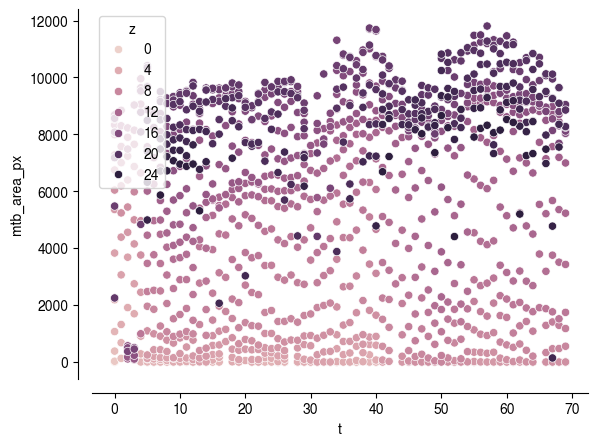

In [169]:
track_ID = 615
sc_df = roi_tracks[roi_tracks['ID'] == track_ID]
sns.scatterplot(data = sc_df, x = 't', y = 'mtb_area_px', hue='z', color='magenta')
sns.despine(offset=10)

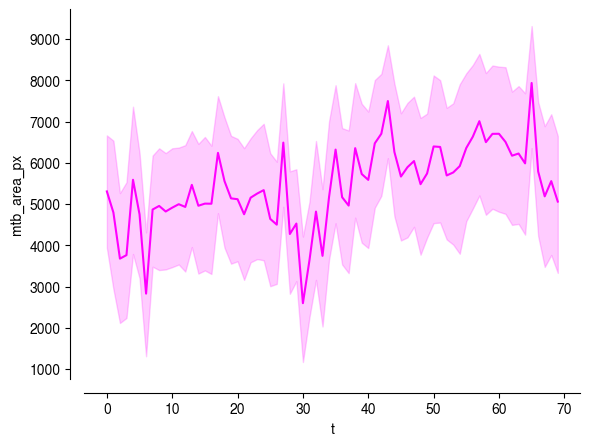

In [166]:
track_ID = 615
sc_df = roi_tracks[roi_tracks['ID'] == track_ID]
sns.lineplot(data = sc_df, x = 't', y = 'mtb_area_px', color='magenta',)
sns.despine(offset=10)

# Process Mtb signals

In [190]:
import importlib
import macrohet.growth_model

importlib.reload(macrohet.growth_model)

from macrohet.growth_model import (
    collate_tracks_to_df,
    compute_doubling_metrics,
    fit_lowess,
    process_mtb_area,
)


### Add scale to df

In [299]:
px_size_um = 0.14949
px_area_um2 = px_size_um ** 2
frame_rate = 0.5
# add new column in µm²
roi_tracks['Mtb Area (µm)'] = roi_tracks['mtb_area_px'] * px_area_um2
roi_tracks['Time (hours)'] = roi_tracks['t'] * frame_rate

/tmp/ipykernel_7320/469547302.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['Mtb Area (µm)'] = roi_tracks['mtb_area_px'] * px_area_um2
/tmp/ipykernel_7320/469547302.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_tracks['Time (hours)'] = roi_tracks['t'] * frame_rate


In [426]:
df = roi_tracks

In [427]:
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours)
0,0,237,1,1411.0,1358.0,8900.0,0.0,1195.0,3.0,3.0,0.000000,0.0
48,48,237,1,1397.0,1346.0,14850.0,0.0,782.0,3.0,3.0,0.000000,24.0
73,73,237,1,1414.0,1352.0,6150.0,0.0,958.0,3.0,3.0,0.000000,36.5
75,75,237,1,1407.0,1347.0,6750.0,0.0,932.0,3.0,3.0,0.000000,37.5
95,95,237,1,1396.0,1348.0,22325.0,0.0,718.0,3.0,3.0,0.000000,47.5
...,...,...,...,...,...,...,...,...,...,...,...,...
50,50,7675,24,187.0,86.0,11300.0,4457.0,1994.0,3.0,3.0,99.601738,25.0
51,51,7675,24,186.0,86.0,10675.0,4510.0,1835.0,3.0,3.0,100.786143,25.5
52,52,7675,24,188.0,85.0,9750.0,4244.0,1902.0,3.0,3.0,94.841772,26.0
56,56,7675,24,183.0,83.0,11625.0,5013.0,1841.0,3.0,3.0,112.026815,28.0


### Add Z discernible IDs and store OG ID

In [428]:
df = df.copy()  # avoid SettingWithCopyWarning

# element-wise concatenation
df['ID_og'] = df['ID']
df["ID"] = df["ID"].astype(str) + "_" + df["z"].astype(str)

print(df[["ID", "z"]].head())


       ID  z
0   237_1  1
48  237_1  1
73  237_1  1
75  237_1  1
95  237_1  1


### Process Mtb signal 

In [430]:
df = df.copy()
df["Mtb Area Processed (µm)"] = np.nan  # new column

for ID in tqdm(df['ID'].unique(), total=df['ID'].nunique()):
    mask = df['ID'] == ID
    sc_df = df.loc[mask]

    if len(sc_df) < 10:
        continue

    s  = sc_df['Mtb Area (µm)']
    rm = s.rolling(window=10, min_periods=1).mean()

    spike = s > 2.0 * rm
    iso0  = (s == 0) & (s.shift(1) > 0) & (s.shift(-1) > 0)

    cleaned = (s.mask(spike | iso0)
                 .interpolate()
                 .bfill()
                 .ffill())

    # assign cleaned back into df for this ID
    df.loc[mask, "Mtb Area Processed (µm)"] = cleaned.values


  0%|          | 0/1241 [00:00<?, ?it/s]

<Axes: xlabel='Time (hours)', ylabel='Mtb Area (µm)'>

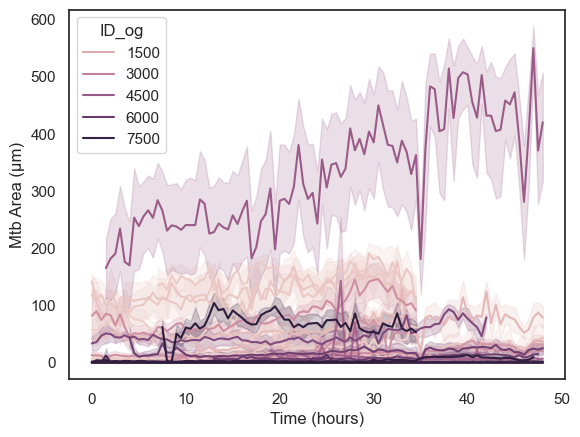

In [431]:
sns.lineplot(data=df, x='Time (hours)', y = 'Mtb Area (µm)', hue='ID_og')
sns.despine(offset=10)


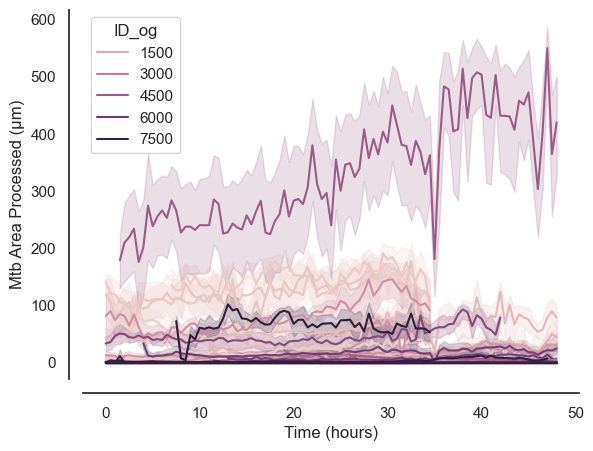

In [432]:
# ---- plot
sns.set_theme(style="white")
ax = sns.lineplot(
    data=df.dropna(subset=["Time (hours)", "Mtb Area Processed (µm)"]), 
    x="Time (hours)", y="Mtb Area Processed (µm)",
    hue="ID_og",
)
sns.despine(offset=10)


### Fit LOWESS growth models to Mtb growth

In [433]:
frac=0.25
default_window=10
control_window=5
import statsmodels.api as sm
from sklearn.metrics import r2_score

df = df.copy()
df["Time Model (hours)"] = np.nan
df["Mtb Area Model (µm)"] = np.nan
df["r2"] = np.nan

for ID in tqdm(df["ID"].unique(), desc="Fitting LOWESS"):
    sc_df = df[df["ID"] == ID]

    if isinstance(ID, str) and "PS0000" in ID:
        window = control_window
    else:
        window = default_window

    time = sc_df["Time (hours)"].values
    pop = sc_df["Mtb Area Processed (µm)"].values
    if len(time) < 10:
        continue

    model = sm.nonparametric.lowess(endog=pop, exog=time, frac=frac)
    time_model = model[:, 0] - (window / 2) + 0.5
    population_model = np.clip(model[:, 1], 0, None)

    if len(time_model) < len(sc_df):
        pad = len(sc_df) - len(time_model)
        time_model = np.concatenate(
            [np.full(pad // 2, np.nan), time_model, np.full(pad - pad // 2, np.nan)]
        )
        population_model = np.concatenate(
            [np.full(pad // 2, np.nan), population_model, np.full(pad - pad // 2, np.nan)]
        )

    df.loc[df["ID"] == ID, "Time Model (hours)"] = time_model
    df.loc[df["ID"] == ID, "Mtb Area Model (µm)"] = population_model
    df.loc[df["ID"] == ID, "r2"] = r2_score(
        sc_df["Mtb Area Processed (µm)"].dropna(), model[:, 1]
    )

Fitting LOWESS:   0%|          | 0/1241 [00:00<?, ?it/s]

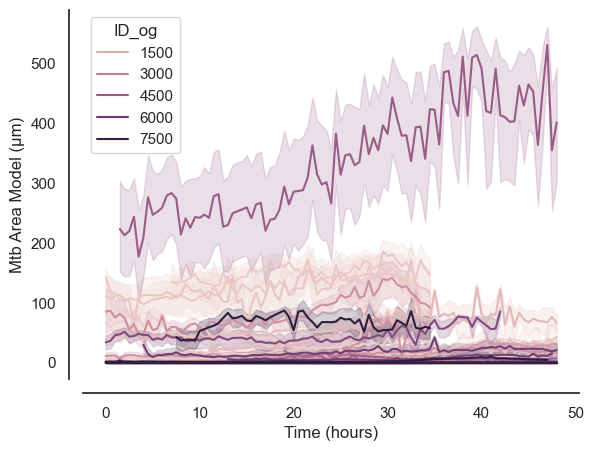

In [434]:
sns.lineplot(data=df.dropna(subset=["Time (hours)", "Mtb Area Model (µm)"]), 
            x='Time (hours)', y = 'Mtb Area Model (µm)', hue='ID_og')
sns.despine(offset=10)

### Compute doubling metrics from growth model

In [440]:
r2_threshold = 0.7
min_area = 1.92
df = df.copy()
# df["Doubling Amounts"] = None
# df["Doubling Times"] = None

df = df.astype('object')
results = []

for ID in tqdm(df["ID"].unique(), desc="Doubling Metrics"):
    sc_df = df[df["ID"] == ID].dropna(
        subset=[
            "Time Model (hours)",
            "Mtb Area Model (\u00b5m)",
            "Mtb Area Processed (\u00b5m)",
        ]
    )
    if sc_df.empty:
        continue

    r2 = sc_df["r2"].iloc[0]
    if r2 < r2_threshold:
        continue

    min_val = max(sc_df["Mtb Area Model (\u00b5m)"].min(), min_area)
    max_val = sc_df["Mtb Area Model (\u00b5m)"].max()
    if max_val <= min_val:
        continue

    N_series = []
    N_i = min_val
    while N_i <= max_val:
        N_series.append(N_i)
        N_i *= 2

    if len(N_series) < 2:
        continue

    times = sc_df["Time Model (hours)"]
    model_vals = sc_df["Mtb Area Model (\u00b5m)"]

    doubling_idx = [np.abs(model_vals - val).idxmin() for val in N_series]
    doubling_times = (
        times.loc[doubling_idx].diff().dropna().values.tolist()
    )

    results.append(
        {
            "ID": ID,
            "Doubling Amounts": N_series,
            "Doubling Times": doubling_times,
        }
    )

results_df = pd.DataFrame(results)
# Merge results back into df by ID
df = df.merge(results_df, on="ID", how="left")


Doubling Metrics:   0%|          | 0/1241 [00:00<?, ?it/s]

In [483]:
subset_df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),ID_og,Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times,binned_z
1320,0,313_1,1,175.0,253.0,14225.0,1256.0,473.0,3.0,3.0,28.068159,0.0,313,28.068159,-4.5,28.068159,1.0,"[1.92, 3.84, 7.68, 15.36]",7.0,"(0.977, 4.833]"
1423,0,313_5,5,175.0,253.0,13925.0,5203.0,473.0,3.0,3.0,116.272794,0.0,313,116.272794,-4.5,109.411884,0.764925,"[7.6515801445929785, 15.303160289185957, 30.60...",11.5,"(4.833, 8.667]"
2177,0,313_17,17,175.0,253.0,4350.0,0.0,473.0,3.0,3.0,0.0,0.0,313,0.0,-4.5,0.0,0.894214,"[1.92, 3.84, 7.68, 15.36, 30.72]",9.5,"(16.333, 20.167]"
2177,0,313_17,17,175.0,253.0,4350.0,0.0,473.0,3.0,3.0,0.0,0.0,313,0.0,-4.5,0.0,0.894214,"[1.92, 3.84, 7.68, 15.36, 30.72]",3.0,"(16.333, 20.167]"
2177,0,313_17,17,175.0,253.0,4350.0,0.0,473.0,3.0,3.0,0.0,0.0,313,0.0,-4.5,0.0,0.894214,"[1.92, 3.84, 7.68, 15.36, 30.72]",25.0,"(16.333, 20.167]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58481,18,7675_21,21,199.0,116.0,2375.0,0.0,1754.0,3.0,3.0,0.0,9.0,7675,0.0,4.5,0.0,0.959378,"[1.92, 3.84, 7.68, 15.36, 30.72, 61.44, 122.88]",5.5,"(20.167, 24.0]"
58501,19,7675_22,22,201.0,133.0,6225.0,0.0,1723.0,3.0,3.0,0.0,9.5,7675,0.0,5.0,0.117253,0.977631,"[1.92, 3.84, 7.68, 15.36, 30.72, 61.44, 122.88]",9.0,"(20.167, 24.0]"
58501,19,7675_22,22,201.0,133.0,6225.0,0.0,1723.0,3.0,3.0,0.0,9.5,7675,0.0,5.0,0.117253,0.977631,"[1.92, 3.84, 7.68, 15.36, 30.72, 61.44, 122.88]",6.5,"(20.167, 24.0]"
58519,19,7675_23,23,201.0,133.0,3900.0,0.0,1723.0,3.0,3.0,0.0,9.5,7675,0.0,5.0,0.0,0.713071,"[1.92, 3.84, 7.68, 15.36, 30.72, 61.44, 122.88]",12.5,"(20.167, 24.0]"


/tmp/ipykernel_7320/36844909.py:31: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


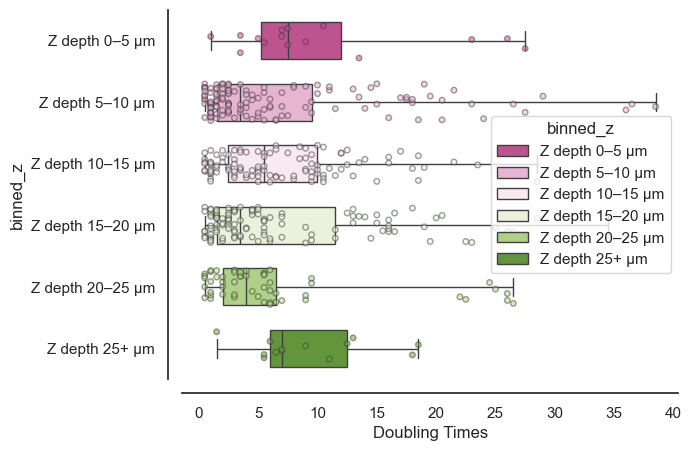

In [491]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode(["Doubling Times"])
)

subset_df = subset_df[(subset_df['Doubling Times'] > 0) &
                      (subset_df['r2'] >= 0.7)]

labels = [
    "Z depth 0–5 µm",
    "Z depth 5–10 µm",
    "Z depth 10–15 µm",
    "Z depth 15–20 µm",
    "Z depth 20–25 µm",
    "Z depth 25+ µm"
]

subset_df["binned_z"] = pd.cut(subset_df["z"], bins=6, labels=labels)

sns.boxplot(
    data=subset_df,
    x="Doubling Times", 
    y="binned_z", 
    hue="binned_z", 
    whis=[0, 100], width=0.6,
    palette='PiYG',
    legend=True
)

sns.stripplot(
    data=subset_df, x="Doubling Times", size=4, hue="binned_z", y="binned_z",
    palette='PiYG', alpha=0.5,
    edgecolor='gray', linewidth=1, jitter=0.3, legend=False
    
)
sns.despine(offset=10)



In [492]:
for layer in viewer_2.layers:
    layer.scale = [1, 0.14949, 0.14949]

In [494]:
# --- Scale bar settings ---
viewer_2.scale_bar.visible = True
viewer_2.scale_bar.unit = "µm"
viewer_2.scale_bar.position = "bottom_right"
viewer_2.scale_bar.font_size = 20
viewer_2.scale_bar.color = "white"
viewer_2.scale_bar.ticks = False  # remove tick marks

# --- Time stamp overlay ---
viewer_2.text_overlay.visible = True
viewer_2.text_overlay.position = "bottom_left"
viewer_2.text_overlay.font_size = 20
viewer_2.text_overlay.color = "white"

# Function to update timestamp when slider moves
def update_slider(event):
    t = viewer_2.dims.current_step[0]/2  # assuming time is axis 0
    viewer_2.text_overlay.text = f"{t:1.2f} hrs"

viewer_2.dims.events.current_step.connect(update_slider)

<function update_slider at 0x76ebcb7ad090>

Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:59<00:00,  3.43it/s]


Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 289/289 [01:28<00:00,  3.27it/s]


Rendering frames...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 385/385 [01:58<00:00,  3.25it/s]


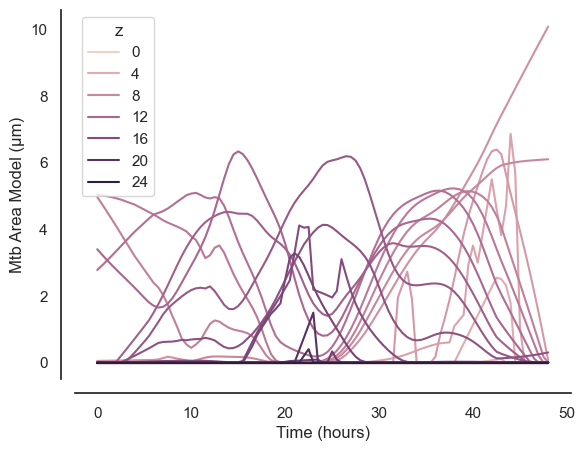

In [498]:
sns.lineplot(data=df[df['ID_og']==2280], x = 'Time (hours)', y = 'Mtb Area Model (µm)', hue='z')
sns.despine(offset=10)

/tmp/ipykernel_7320/3072619708.py:27: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.15, right=1, top=-0.95, bottom=0.1)
/tmp/ipykernel_7320/3072619708.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


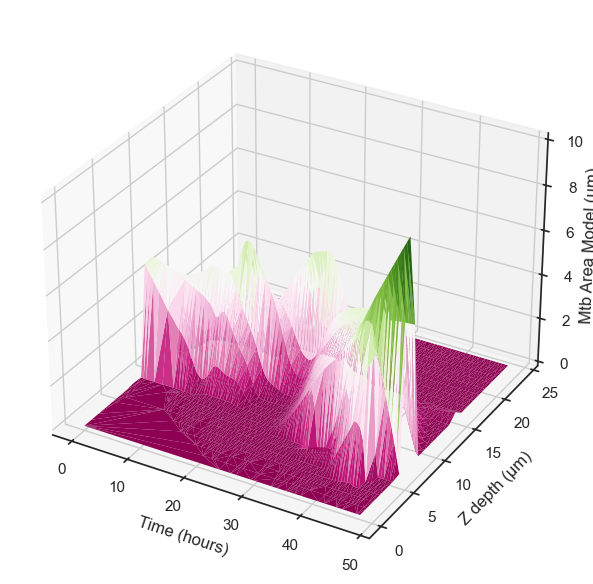

In [526]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots
import numpy as np
# subset & coerce to numeric
df_sub = df.loc[df["ID_og"] == 2280, ["Time (hours)", "Mtb Area Model (µm)", "z"]].copy()
for c in ["Time (hours)", "Mtb Area Model (µm)", "z"]:
    df_sub[c] = pd.to_numeric(df_sub[c], errors="coerce")
df_sub = df_sub.dropna()

# numpy arrays (float)
x = df_sub["Time (hours)"].to_numpy(dtype=float)
z = df_sub["Mtb Area Model (µm)"].to_numpy(dtype=float)
y = df_sub["z"].to_numpy(dtype=float)

# 3D surface from irregular points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(6, 6), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_trisurf(x, y, z, cmap="PiYG", edgecolor="none")

ax.set_xlabel("Time (hours)", labelpad=5)
ax.set_zlabel("Mtb Area Model (µm)", labelpad=0)
ax.set_ylabel("Z depth (µm)", labelpad=5,)
plt.subplots_adjust(left=0.15, right=1, top=-0.95, bottom=0.1)

# fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, label="Z depth (µm)")
plt.tight_layout()
plt.show()


In [500]:
z_data

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,0,27.809850,49.619360,83.080670,116.66320,130.41400,150.72060,220.18710,156.15360,148.64160,...,49.961420,21.89279,17.025520,11.743170,14.752260,13.667100,5.677561,3.312340,1.156517,-0.147662
1,1,27.719660,48.550220,65.213740,95.27666,116.99640,133.90560,152.34120,151.93400,160.11390,...,33.088710,38.40972,44.248430,69.578600,4.019351,3.050024,3.039719,2.996142,2.967954,1.999594
2,2,30.426700,33.477520,44.809530,62.47495,77.43523,104.21530,102.73930,137.00040,186.07060,...,48.471320,74.71461,60.090900,7.073525,6.089851,6.537450,6.666096,7.306965,5.736840,3.625628
3,3,16.665490,30.108600,39.969520,44.12225,59.57512,77.56929,106.89250,166.55390,175.23810,...,60.559160,55.92124,15.172840,8.248324,36.680870,61.934130,20.268670,68.588190,46.498120,0.236010
4,4,8.815617,18.351600,8.658275,27.58590,48.62691,60.18013,91.32860,145.71090,116.06530,...,47.426910,69.20731,44.954680,29.171970,17.916740,16.255150,14.655590,17.260480,31.222450,46.717040
5,5,6.628881,10.413390,24.819390,26.08952,30.16050,52.30802,64.71007,76.30823,84.63686,...,140.264700,81.26501,56.457560,30.421640,17.287820,8.302431,2.981626,2.698536,5.886086,5.268358
6,6,21.839750,6.639270,18.970850,32.89204,43.15014,62.86014,104.66570,130.22940,114.84940,...,122.422100,123.96980,109.095200,98.419560,77.613740,32.490310,14.673440,7.370775,0.037110,0.642339
7,7,53.343030,26.797970,6.639270,10.88787,17.20440,56.18116,79.70141,90.84530,98.27675,...,68.174900,46.24076,39.938570,31.216530,36.883350,40.025250,117.429700,12.703280,1.729771,0.000000
8,8,25.667850,63.057170,22.141400,17.07400,41.74483,60.27227,81.42432,114.44400,102.32340,...,59.193550,42.47175,14.635980,6.944074,6.944075,27.749360,0.000000,0.000000,0.094494,0.077323
9,9,12.827000,69.205540,46.762930,13.96517,33.88744,61.82613,84.74799,121.12200,145.27410,...,79.344250,25.93483,6.944074,6.944074,6.944075,7.553681,0.000000,0.000000,0.000000,0.000000


# to-do: 

1. Inspect individual sc graphs
2. Make animations